In [1]:
import os

print(os.listdir())

['.config', 'sample_data']


In [3]:
# ==================================================
# 1. IMPORTS
# ==================================================
import os
import re
import math
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Try importing gradient boosters (gracefully skip if unavailable)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

# ==================================================
# 2. CONFIGURATION
# ==================================================
RANDOM_SEED = 42
plt.style.use('ggplot')

# ==================================================
# 3. LOAD DATASET
# ==================================================
print("Loading dataset...")
# Reading without header as specified, assigning logical columns
DATA_FILE = "dga_domains_full.csv"

df = pd.read_csv(
    DATA_FILE,
    header=None,
    names=['label', 'family', 'domain']
)

# ==================================================
# 4. DATASET INSPECTION & 5. DATA CLEANING
# ==================================================
print(f"Original Dataset Shape: {df.shape}")

# Normalize domains: lowercase, strip whitespace
df['domain'] = df['domain'].astype(str).str.lower().str.strip()

# Drop rows with missing crucial values
initial_rows = len(df)
df = df.dropna(subset=['domain', 'label'])
missing_dropped = initial_rows - len(df)

# Handle missing family (assign 'unknown' to prevent errors in family-aware splits)
df['family'] = df['family'].fillna('unknown')

# ==================================================
# 6. DUPLICATE & CONFLICT CHECKS
# ==================================================
# Check for conflicts: domain in both DGA and Legit
domain_labels = df.groupby('domain')['label'].nunique()
conflicts = domain_labels[domain_labels > 1].index.tolist()
print(f"Conflicting domains found (DGA & Legit): {len(conflicts)}")

# Remove conflicts entirely to maintain clean ground truth
df = df[~df['domain'].isin(conflicts)]

# Remove remaining duplicates
pre_dedup_rows = len(df)
df = df.drop_duplicates(subset=['domain'], keep='first')
duplicates_removed = pre_dedup_rows - len(df)

print("\n--- Data Cleaning Summary ---")
print(f"Total rows before cleaning: {initial_rows}")
print(f"Rows dropped due to missing values: {missing_dropped}")
print(f"Conflicting rows removed: {len(conflicts) * 2}") # Approx
print(f"Duplicates removed: {duplicates_removed}")
print(f"Total rows after cleaning: {len(df)}")

print("\n--- Class Distribution ---")
class_counts = df['label'].value_counts()
print(class_counts)
print(f"DGA Percentage: {(class_counts.get('dga', 0) / len(df) * 100):.2f}%")
print(f"Legit Percentage: {(class_counts.get('legit', 0) / len(df) * 100):.2f}%")

print(f"\nNumber of DGA Families: {df[df['label'] == 'dga']['family'].nunique()}")

# ==================================================
# 7. TLD ANALYSIS (For Analysis Only)
# ==================================================
def extract_tld(domain):
    parts = domain.rsplit('.', 1)
    return parts[-1] if len(parts) > 1 else 'none'

df['tld'] = df['domain'].apply(extract_tld)
print("\n--- Top TLDs (DGA vs Legit) ---")
print("DGA TLDs:\n", df[df['label'] == 'dga']['tld'].value_counts().head(5))
print("Legit TLDs:\n", df[df['label'] == 'legit']['tld'].value_counts().head(5))
# Drop TLD to strictly prevent it from becoming an ML feature
df = df.drop(columns=['tld'])

# ==================================================
# 8. DGA FAMILY ANALYSIS
# ==================================================
print("\n--- Top DGA Families ---")
print(df[df['label'] == 'dga']['family'].value_counts().head(10))

Loading dataset...
Original Dataset Shape: (106397, 3)
Conflicting domains found (DGA & Legit): 0

--- Data Cleaning Summary ---
Total rows before cleaning: 106397
Rows dropped due to missing values: 0
Conflicting rows removed: 0
Duplicates removed: 1
Total rows after cleaning: 106396

--- Class Distribution ---
label
dga      53206
legit    53190
Name: count, dtype: int64
DGA Percentage: 50.01%
Legit Percentage: 49.99%

Number of DGA Families: 25

--- Top TLDs (DGA vs Legit) ---
DGA TLDs:
 tld
com    17894
net     9480
org     4540
ru      3397
eu      2664
Name: count, dtype: int64
Legit TLDs:
 tld
com    27089
net     2501
org     2421
ru      2176
de      1721
Name: count, dtype: int64

--- Top DGA Families ---
family
matsnu      2232
fobber      2199
nymaim      2175
suppobox    2173
ramdo       2159
ramnit      2158
symmi       2147
emotet      2144
gozi        2142
pushdo      2140
Name: count, dtype: int64


In [4]:
# ==================================================
# 9. FEATURE ENGINEERING
# ==================================================
def remove_tld(domain):
    """Removes the TLD to prevent bias in lexical features."""
    parts = domain.rsplit('.', 1)
    return parts[0] if len(parts) > 1 else domain

def extract_dga_features(domain):
    """Extracts 10 lexical features from the domain (excluding TLD)."""
    core_domain = remove_tld(str(domain))
    domain_length = len(core_domain)

    if domain_length == 0:
        return [0]*10

    digit_count = sum(c.isdigit() for c in core_domain)
    digit_ratio = digit_count / domain_length

    vowels = set('aeiouy')
    vowel_count = sum(1 for c in core_domain if c in vowels)
    vowel_ratio = vowel_count / domain_length

    consonants = set('bcdfghjklmnpqrstvwxz')
    consonant_count = sum(1 for c in core_domain if c in consonants)
    consonant_ratio = consonant_count / domain_length

    counts = Counter(core_domain)
    entropy = -sum((count / domain_length) * math.log2(count / domain_length) for count in counts.values())

    unique_char_ratio = len(counts) / domain_length
    hyphen_count = core_domain.count('-')

    labels = core_domain.split('.')
    label_count = len(labels)
    longest_label_length = max((len(lbl) for lbl in labels), default=0)

    return [domain_length, digit_count, digit_ratio, vowel_ratio, consonant_ratio,
            entropy, unique_char_ratio, hyphen_count, label_count, longest_label_length]

# ==================================================
# 10. TRAIN / VALIDATION / TEST SPLIT
# ==================================================
# Convert labels to binary (1 = DGA, 0 = Legit)
df['target'] = (df['label'] == 'dga').astype(int)

# 70/15/15 Split using Stratification
X_main, X_test_raw, y_main, y_test = train_test_split(
    df[['domain', 'family']], df['target'], test_size=0.15, stratify=df['target'], random_state=RANDOM_SEED
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_main, y_main, test_size=0.1765, stratify=y_main, random_state=RANDOM_SEED # 0.1765 of 0.85 approx 0.15
)

# ==================================================
# 11. N-GRAM BASELINE CONSTRUCTION (LEAKAGE PREVENTION)
# ==================================================
# CRITICAL: Build N-gram model strictly on the TRAINING set LEGITIMATE domains.
class NgramScorer:
    def __init__(self, n=2):
        self.n = n
        self.probs = {}

    def fit(self, domains):
        counts = defaultdict(int)
        total = 0
        for dom in domains:
            core = remove_tld(dom)
            for i in range(len(core) - self.n + 1):
                counts[core[i:i+self.n]] += 1
                total += 1
        self.probs = {k: v / total for k, v in counts.items()}

    def score(self, domain):
        core = remove_tld(domain)
        if len(core) < self.n:
            return 0.0
        score_val = 0.0
        for i in range(len(core) - self.n + 1):
            gram = core[i:i+self.n]
            # Use small epsilon (1e-6) for unseen n-grams
            p = self.probs.get(gram, 1e-6)
            score_val += math.log10(p)
        return score_val / (len(core) - self.n + 1)

print("Fitting N-gram models on Training Set Legitimate domains...")
legit_train_domains = X_train_raw[y_train == 0]['domain'].tolist()
bigram_model = NgramScorer(n=2)
bigram_model.fit(legit_train_domains)

trigram_model = NgramScorer(n=3)
trigram_model.fit(legit_train_domains)

# Apply feature extraction
def build_feature_matrix(df_raw):
    features = []
    for dom in df_raw['domain']:
        base_feats = extract_dga_features(dom)
        b_score = bigram_model.score(dom)
        t_score = trigram_model.score(dom)
        features.append(base_feats + [b_score, t_score])

    cols = ['domain_length', 'digit_count', 'digit_ratio', 'vowel_ratio', 'consonant_ratio',
            'entropy', 'unique_char_ratio', 'hyphen_count', 'label_count', 'longest_label_length',
            'bigram_score', 'trigram_score']
    return pd.DataFrame(features, columns=cols)

print("Extracting features for Train, Val, Test...")
X_train = build_feature_matrix(X_train_raw)
X_val = build_feature_matrix(X_val_raw)
X_test = build_feature_matrix(X_test_raw)

Fitting N-gram models on Training Set Legitimate domains...
Extracting features for Train, Val, Test...


Training and Tuning models...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:41:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...
[LightGBM] [Info] Number of positive: 37243, number of negative: 37231
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1478
[LightGBM] [Info] Number of data points in the train set: 74474, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500081 -> initscore=0.000322
[LightGBM] [Info] Start training from score 0.000322

--- Validation Performance ---
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
      Random Forest  0.888798   0.933389 0.837384 0.882784 0.950069
            XGBoost  0.884538   0.918473 0.844024 0.879676 0.950526
           LightGBM  0.884225   0.917620 0.844275 0.879421 0.949361
  Gradient Boosting  0.881719   0.924965 0.830869 0.875396 0.944740
      Decision Tree  0.877647   0.916770 0.830744 0.871640 0.928594
Logistic Regression  0.855595   0.873241 0.8319

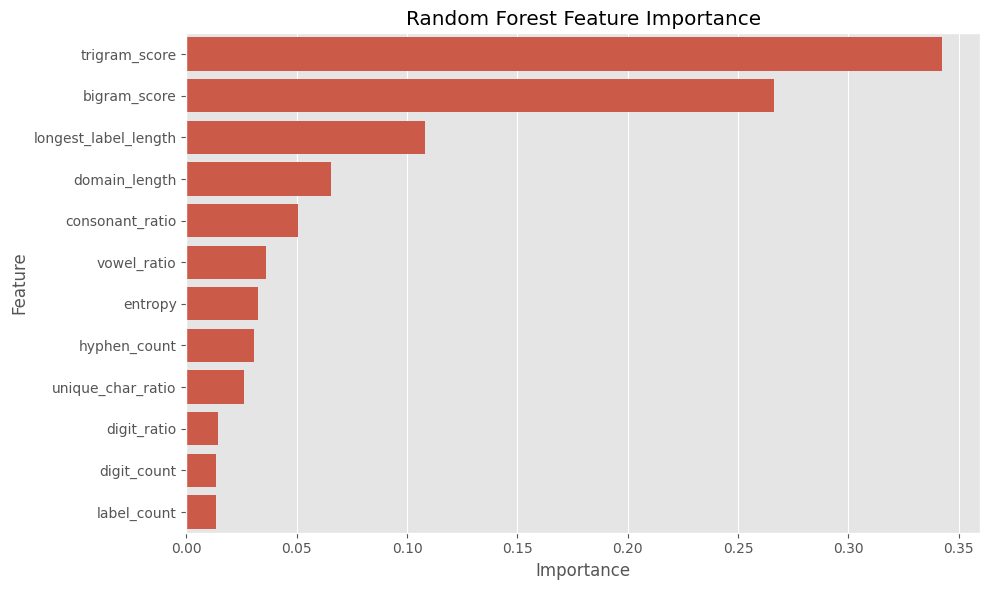

In [5]:
# ==================================================
# 12. MODEL TRAINING & 13. HYPERPARAMETER TUNING
# ==================================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_SEED)
}

if HAS_XGB:
    models['XGBoost'] = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED)
if HAS_LGB:
    models['LightGBM'] = lgb.LGBMClassifier(random_state=RANDOM_SEED)

# Hyperparameter grids (small to prevent hours of training)
param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Decision Tree': {'max_depth': [10, 20, None]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [15, None]},
    'Gradient Boosting': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]},
    'XGBoost': {'n_estimators': [50, 100], 'max_depth': [6, 10]},
    'LightGBM': {'n_estimators': [50, 100], 'num_leaves': [31, 50]}
}

best_estimators = {}
results = []

print("Training and Tuning models...")
for name, model in models.items():
    print(f"Training {name}...")
    # RandomizedSearchCV for efficiency
    grid = RandomizedSearchCV(model, param_grids.get(name, {}), n_iter=3, cv=3, scoring='f1', n_jobs=-1, random_state=RANDOM_SEED)
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_

    # Evaluate on Validation Set for comparison table
    y_val_pred = grid.predict(X_val)
    y_val_prob = grid.predict_proba(X_val)[:, 1] if hasattr(grid, "predict_proba") else y_val_pred

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred),
        'Recall': recall_score(y_val, y_val_pred),
        'F1': f1_score(y_val, y_val_pred),
        'ROC-AUC': roc_auc_score(y_val, y_val_prob)
    })

# ==================================================
# 14. MODEL COMPARISON
# ==================================================
results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
print("\n--- Validation Performance ---")
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison.csv', index=False)

# ==================================================
# 16. FEATURE IMPORTANCE
# ==================================================
best_rf = best_estimators.get('Random Forest')
if best_rf:
    importances = best_rf.feature_importances_
    feat_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp)
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    print("\n--- Feature Importance Saved to feature_importance.png ---")

In [6]:
# ==================================================
# 17. FAMILY-UNSEEN EVALUATION
# ==================================================

# Hold out selected DGA families completely
unseen_families = ['gozi', 'suppobox']

# DGA families other than the unseen ones
seen_mask = ~(
    (df['label'] == 'dga') &
    (df['family'].isin(unseen_families))
)

# Completely unseen DGA samples
unseen_mask = (
    (df['label'] == 'dga') &
    (df['family'].isin(unseen_families))
)

df_seen = df[seen_mask].copy()
df_unseen = df[unseen_mask].copy()

print("\n--- Family-Unseen Evaluation ---")
print(f"Seen samples: {len(df_seen)}")
print(f"Unseen DGA samples: {len(df_unseen)}")

# --------------------------------------------------
# Split seen data into training and testing
# --------------------------------------------------
X_seen_train, X_seen_test, y_seen_train, y_seen_test = train_test_split(
    df_seen[['domain']],
    df_seen['target'],
    test_size=0.20,
    stratify=df_seen['target'],
    random_state=RANDOM_SEED
)

# --------------------------------------------------
# Leakage-free N-gram models
# Train ONLY on legitimate domains from seen training data
# --------------------------------------------------
unseen_bg = NgramScorer(n=2)
unseen_tg = NgramScorer(n=3)

legit_seen = X_seen_train[
    y_seen_train == 0
]['domain'].tolist()

unseen_bg.fit(legit_seen)
unseen_tg.fit(legit_seen)


# --------------------------------------------------
# Feature builder for unseen-family experiment
# --------------------------------------------------
def build_unseen_features(domains):

    feats = []

    for dom in domains:

        base_features = extract_dga_features(dom)

        b_score = unseen_bg.score(dom)
        t_score = unseen_tg.score(dom)

        feats.append(
            base_features + [b_score, t_score]
        )

    return pd.DataFrame(
        feats,
        columns=[
            'domain_length',
            'digit_count',
            'digit_ratio',
            'vowel_ratio',
            'consonant_ratio',
            'entropy',
            'unique_char_ratio',
            'hyphen_count',
            'label_count',
            'longest_label_length',
            'bigram_score',
            'trigram_score'
        ]
    )


# --------------------------------------------------
# Train Random Forest on SEEN families only
# --------------------------------------------------
rf_unseen = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=RANDOM_SEED
)

rf_unseen.fit(
    build_unseen_features(X_seen_train['domain']),
    y_seen_train
)


# --------------------------------------------------
# Test ONLY on completely unseen DGA families
# --------------------------------------------------
X_unseen_test = df_unseen.copy()

y_unseen_test = np.ones(
    len(X_unseen_test),
    dtype=int
)

X_unseen_test_feats = build_unseen_features(
    X_unseen_test['domain']
)

unseen_preds = rf_unseen.predict(
    X_unseen_test_feats
)


# --------------------------------------------------
# Unseen-family recall
# --------------------------------------------------
if len(y_unseen_test) > 0:

    unseen_recall = recall_score(
        y_unseen_test,
        unseen_preds,
        zero_division=0
    )

    print(
        f"Recall on completely unseen DGA families "
        f"({unseen_families}): {unseen_recall:.4f}"
    )

else:

    print("No samples found for the selected unseen families.")


# ==================================================
# 18. FINAL MODEL SELECTION & TEST EVALUATION
# ==================================================

final_test_results = []

for name, model in best_estimators.items():

    # Predictions
    y_test_pred = model.predict(X_test)

    # Probabilities
    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_test_prob = y_test_pred

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_test_pred
    )

    final_test_results.append({

        'Model': name,

        'Accuracy': accuracy_score(
            y_test,
            y_test_pred
        ),

        'Precision': precision_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        'Recall': recall_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        'F1-score': f1_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        'ROC-AUC': roc_auc_score(
            y_test,
            y_test_prob
        ),

        'False Positives': cm[0, 1],

        'False Negatives': cm[1, 0]
    })


# --------------------------------------------------
# Test results table
# --------------------------------------------------
test_df = pd.DataFrame(
    final_test_results
)

test_df = test_df.sort_values(
    by=[
        'F1-score',
        'Recall',
        'ROC-AUC'
    ],
    ascending=[
        False,
        False,
        False
    ]
)

print("\n--- Final Test Performance ---")
print(
    test_df.to_string(index=False)
)


# --------------------------------------------------
# Select best model
# --------------------------------------------------
best_model_name = test_df.iloc[0]['Model']

best_model_obj = best_estimators[
    best_model_name
]

best_stats = test_df.iloc[0]


print("\n========================================")
print("FINAL MODEL SELECTION")
print("========================================")

print(
    f"Selected Model: {best_model_name}\n"
)

print(
    f"Accuracy: {best_stats['Accuracy']:.4f}"
)

print(
    f"Precision: {best_stats['Precision']:.4f}"
)

print(
    f"Recall: {best_stats['Recall']:.4f}"
)

print(
    f"F1-score: {best_stats['F1-score']:.4f}"
)

print(
    f"ROC-AUC: {best_stats['ROC-AUC']:.4f}"
)

print(
    f"False Positives: "
    f"{int(best_stats['False Positives'])}"
)

print(
    f"False Negatives: "
    f"{int(best_stats['False Negatives'])}"
)

print("\nReason for selection:")

print(
    "The final model was selected primarily using "
    "F1-score, with Recall and ROC-AUC used as "
    "secondary criteria. In DGA detection, high "
    "Recall is important because missing malicious "
    "domains can be costly, while Precision helps "
    "control false positives."
)


# ==================================================
# 19. SAVE FINAL MODEL
# ==================================================

pipeline_objects = {

    'model': best_model_obj,

    'bigram_model': bigram_model,

    'trigram_model': trigram_model,

    'features': X_train.columns.tolist()
}

joblib.dump(
    pipeline_objects,
    'final_dga_model.joblib'
)

print(
    "\nModel and pipeline objects saved to "
    "'final_dga_model.joblib'"
)


# ==================================================
# 20. STANDALONE PREDICTION FUNCTION
# ==================================================

def predict_dga(domain):

    """
    Predict whether a domain is DGA or legitimate
    using the saved final model and feature pipeline.
    """

    # Load saved pipeline
    pipeline = joblib.load(
        'final_dga_model.joblib'
    )

    model = pipeline['model']

    bg = pipeline['bigram_model']

    tg = pipeline['trigram_model']


    # Normalize input
    clean_domain = (
        str(domain)
        .lower()
        .strip()
    )


    # Extract base features
    base_feats = extract_dga_features(
        clean_domain
    )

    # N-gram features
    b_score = bg.score(
        clean_domain
    )

    t_score = tg.score(
        clean_domain
    )


    # Create feature vector
    feature_vector = pd.DataFrame(

        [
            base_feats +
            [b_score, t_score]
        ],

        columns=pipeline['features']
    )


    # Prediction
    pred = int(
        model.predict(
            feature_vector
        )[0]
    )


    # Probability
    if hasattr(model, 'predict_proba'):

        prob = float(
            model.predict_proba(
                feature_vector
            )[0][1]
        )

    else:

        prob = float(pred)


    return {

        "domain": domain,

        "prediction":
            "DGA"
            if pred == 1
            else "LEGIT",

        "probability":
            round(prob, 4)
    }


# ==================================================
# 21. TEST WITH EXAMPLE DOMAINS
# ==================================================

print("\n--- Example Predictions ---")

test_domains = [

    "google.com",

    "txumyqrubwutbb.cc",

    "isro.gov.in",

    "x89vf2qlmn3.top"
]


for domain in test_domains:

    print(
        predict_dga(domain)
    )


--- Family-Unseen Evaluation ---
Seen samples: 102081
Unseen DGA samples: 4315
Recall on completely unseen DGA families (['gozi', 'suppobox']): 0.0642

--- Final Test Performance ---
              Model  Accuracy  Precision   Recall  F1-score  ROC-AUC  False Positives  False Negatives
      Random Forest  0.893233   0.934635 0.845633  0.887909 0.951254              472             1232
            XGBoost  0.890977   0.920609 0.855782  0.887013 0.953262              589             1151
           LightGBM  0.888972   0.917889 0.854404  0.885010 0.951123              610             1162
  Gradient Boosting  0.887218   0.928106 0.839494  0.881579 0.948321              519             1281
      Decision Tree  0.880702   0.916632 0.837614  0.875344 0.929921              608             1296
Logistic Regression  0.859962   0.871285 0.844756  0.857815 0.921404              996             1239

FINAL MODEL SELECTION
Selected Model: Random Forest

Accuracy: 0.8932
Precision: 0.9346
Recall

In [7]:
%%writefile app.py
import math
import time
import joblib
import pandas as pd

from collections import Counter
from typing import List, Dict, Any

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel


# ============================================================
# 1. N-GRAM CLASS
# ============================================================

class NgramScorer:

    def __init__(self, n=2):
        self.n = n
        self.probs = {}

    def fit(self, domains):
        pass

    def score(self, domain: str) -> float:

        core = (
            domain.rsplit(".", 1)[0]
            if "." in domain
            else domain
        )

        if len(core) < self.n:
            return 0.0

        score_val = 0.0

        for i in range(len(core) - self.n + 1):

            gram = core[i:i + self.n]

            p = self.probs.get(
                gram,
                1e-6
            )

            score_val += math.log10(p)

        return score_val / (
            len(core) - self.n + 1
        )


# ============================================================
# 2. FIX JOBLIB __main__ REFERENCE
# ============================================================

import __main__

__main__.NgramScorer = NgramScorer


# ============================================================
# 3. LOAD MODEL
# ============================================================

MODEL_FILE = "final_dga_model.joblib"

model_pipeline: Dict[str, Any] = {}

try:

    artifacts = joblib.load(
        MODEL_FILE
    )

    model_pipeline["model"] = (
        artifacts["model"]
    )

    model_pipeline["bigram_model"] = (
        artifacts["bigram_model"]
    )

    model_pipeline["trigram_model"] = (
        artifacts["trigram_model"]
    )

    model_pipeline["features"] = (
        artifacts["features"]
    )

    print(
        "DGA model loaded successfully."
    )

except Exception as e:

    print(
        "ERROR loading DGA model:"
    )

    print(e)


# ============================================================
# 4. FASTAPI
# ============================================================

app = FastAPI(
    title="DGA Detection API",
    version="1.0.0"
)


# ============================================================
# 5. FEATURE EXTRACTION
# ============================================================

def remove_tld(domain: str) -> str:

    parts = domain.rsplit(".", 1)

    return (
        parts[0]
        if len(parts) > 1
        else domain
    )


def extract_features(
    domain: str,
    bigram_model,
    trigram_model,
    feature_names
):

    core_domain = remove_tld(
        domain
    )

    domain_length = len(
        core_domain
    )

    if domain_length == 0:

        return pd.DataFrame(
            [[0] * len(feature_names)],
            columns=feature_names
        )

    digit_count = sum(
        c.isdigit()
        for c in core_domain
    )

    digit_ratio = (
        digit_count /
        domain_length
    )

    vowels = set(
        "aeiouy"
    )

    vowel_count = sum(
        1
        for c in core_domain
        if c in vowels
    )

    vowel_ratio = (
        vowel_count /
        domain_length
    )

    consonants = set(
        "bcdfghjklmnpqrstvwxz"
    )

    consonant_count = sum(
        1
        for c in core_domain
        if c in consonants
    )

    consonant_ratio = (
        consonant_count /
        domain_length
    )

    counts = Counter(
        core_domain
    )

    entropy = -sum(
        (count / domain_length)
        * math.log2(
            count / domain_length
        )
        for count in counts.values()
    )

    unique_char_ratio = (
        len(counts) /
        domain_length
    )

    hyphen_count = (
        core_domain.count("-")
    )

    labels = core_domain.split(
        "."
    )

    label_count = len(
        labels
    )

    longest_label_length = max(
        (
            len(label)
            for label in labels
        ),
        default=0
    )

    bigram_score = (
        bigram_model.score(domain)
    )

    trigram_score = (
        trigram_model.score(domain)
    )

    feature_row = [

        domain_length,
        digit_count,
        digit_ratio,
        vowel_ratio,
        consonant_ratio,
        entropy,
        unique_char_ratio,
        hyphen_count,
        label_count,
        longest_label_length,
        bigram_score,
        trigram_score

    ]

    return pd.DataFrame(
        [feature_row],
        columns=feature_names
    )


# ============================================================
# 6. REQUEST SCHEMA
# ============================================================

class DomainRequest(BaseModel):

    domain: str


# ============================================================
# 7. HEALTH
# ============================================================

@app.get("/health")
def health():

    return {

        "status": "healthy",

        "model_loaded":
            "model" in model_pipeline,

        "features_loaded":
            len(
                model_pipeline.get(
                    "features",
                    []
                )
            )

    }


# ============================================================
# 8. PREDICT
# ============================================================

@app.post("/predict")
def predict(
    payload: DomainRequest
):

    if "model" not in model_pipeline:

        raise HTTPException(
            status_code=500,
            detail="DGA model is not loaded."
        )

    domain = (
        payload.domain
        .lower()
        .strip()
    )

    if not domain:

        raise HTTPException(
            status_code=400,
            detail="Domain cannot be empty."
        )

    start = time.perf_counter()

    features = extract_features(

        domain,

        model_pipeline[
            "bigram_model"
        ],

        model_pipeline[
            "trigram_model"
        ],

        model_pipeline[
            "features"
        ]

    )

    model = model_pipeline[
        "model"
    ]

    prediction = int(
        model.predict(
            features
        )[0]
    )

    if hasattr(
        model,
        "predict_proba"
    ):

        probability = float(
            model.predict_proba(
                features
            )[0][1]
        )

    else:

        probability = float(
            prediction
        )

    latency = (
        time.perf_counter()
        - start
    ) * 1000

    return {

        "domain": payload.domain,

        "prediction":
            "DGA"
            if prediction == 1
            else "LEGIT",

        "probability":
            round(
                probability,
                4
            ),

        "is_dga":
            prediction == 1,

        "latency_ms":
            round(
                latency,
                2
            )

    }


# ============================================================
# 9. RUN SERVER
# ============================================================

if __name__ == "__main__":

    import uvicorn

    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )

Writing app.py


In [10]:
import requests

response = requests.post(
    "https://frame-ferocious-unseemly.ngrok-free.dev/predict",
    json={"domain": "xq7mz9k2p4v8.top"}
)

print(response.status_code)
print(response.json())

200
{'domain': 'xq7mz9k2p4v8.top', 'prediction': 'DGA', 'probability': 0.9997, 'is_dga': True, 'latency_ms': 37.59}


In [11]:
from pyngrok import ngrok

# Yahan APNA NAYA ngrok token daalo
ngrok.set_auth_token("3GPCY6TYef6JPBmmCluujtXYNgu_5hyMvbeiP3jbshwnqCJJi")

# Purane tunnels close
try:
    ngrok.kill()
except:
    pass

# New public tunnel
public_url = ngrok.connect(8000)

print("PUBLIC URL:")
print(public_url)

print("\nSWAGGER DOCS:")
print(str(public_url).split('"')[1] + "/docs")

PUBLIC URL:
NgrokTunnel: "https://frame-ferocious-unseemly.ngrok-free.dev" -> "http://localhost:8000"

SWAGGER DOCS:
https://frame-ferocious-unseemly.ngrok-free.dev/docs
